In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import numpy as np

from gerar_dados_vitimas import gerar_dataset_vitimas


Dataset salvo como datasets\vict\10v\data.csv

Número de vítimas por classificação START:
  0 (verde): 1178
  1 (amarelo): 1757
  2 (vermelho): 2352
  3 (preto): 713


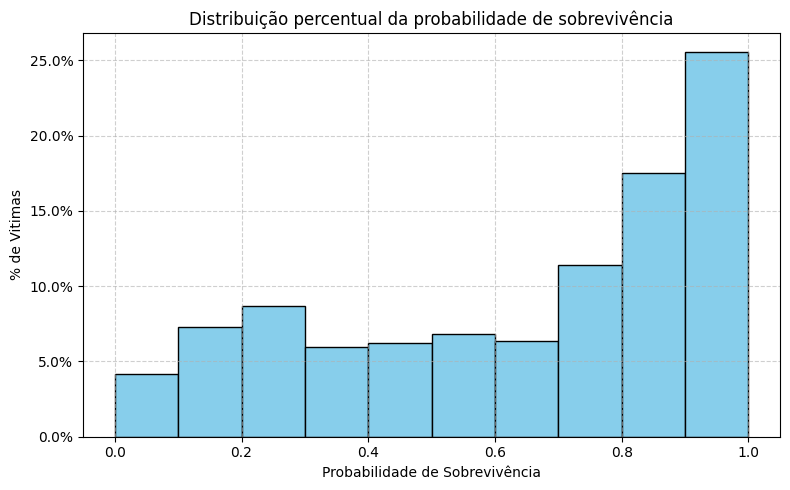

In [2]:
# Parâmetros do dataset (fixos para o trabalho)
N_VITIMAS = 6000
MEDIA_IDADE = 55
DESVIO_IDADE = 8
TIPO_ACIDENTE = "aereo"
NIVEL_RUIDO = 0.07
SEED_TREINO = 50
SEED_TESTE = 89

# Dataset de treino/validação
df_treino_val = gerar_dataset_vitimas(
    n_vitimas=N_VITIMAS,
    media_idade=MEDIA_IDADE,
    desvio_idade=DESVIO_IDADE,
    tipo_acidente=TIPO_ACIDENTE,
    nivel_ruido=NIVEL_RUIDO,
    seed=SEED_TREINO
)

In [3]:
print("Formato do dataset:", df_treino_val.shape)
display(df_treino_val.head())
display(df_treino_val.describe())

Formato do dataset: (6000, 14)


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
0,54,112,24,105,93,37.747571,0,2,1,0,13,0,1,0.90
1,61,129,28,85,98,37.517449,0,1,1,0,13,0,1,0.89
2,58,106,19,99,86,36.882684,1,2,1,0,13,1,1,0.76
3,67,110,25,87,90,38.323400,0,1,0,1,13,1,1,0.86
4,70,117,22,100,96,37.801619,0,1,0,0,13,1,1,0.68


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,54.656667,104.503833,25.449833,83.018167,82.712500,35.404802,0.337333,1.977333,0.794833,0.843000,11.227333,1.272000,1.433333,0.639628
std,8.781874,43.207196,12.462559,33.971172,19.114272,2.700660,0.472839,1.193618,0.403857,1.218441,3.184600,1.049222,0.935967,0.297620
min,22.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,49.000000,88.000000,17.000000,70.000000,79.000000,34.161480,0.000000,1.000000,1.000000,0.000000,10.000000,0.000000,1.000000,0.380000
50%,54.000000,113.000000,26.000000,88.000000,87.000000,35.697765,0.000000,3.000000,1.000000,0.000000,11.000000,2.000000,2.000000,0.740000
75%,61.000000,135.000000,36.000000,107.000000,94.000000,37.383626,1.000000,3.000000,1.000000,2.000000,13.000000,2.000000,2.000000,0.900000
max,83.000000,173.000000,47.000000,143.000000,100.000000,39.607864,1.000000,3.000000,1.000000,3.000000,15.000000,3.000000,3.000000,1.000000


In [4]:
# variável alvo (target)
y = df_treino_val["sobr"]

# colunas proibidas pelo trabalho
colunas_proibidas = ["gcs", "avpu", "tri", "sobr"]

# features (entradas)
X = df_treino_val.drop(columns=colunas_proibidas)

print("Features utilizadas:")
print(list(X.columns))

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

Features utilizadas:
['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']

Formato de X: (6000, 10)
Formato de y: (6000,)


## 2. Modelo CART
Primeiro realizamos a busca exaustiva para encontrar os melhores hiperparâmetros via Validação Cruzada.

In [6]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.tree import DecisionTreeRegressor
from itertools import product

kf = KFold(n_splits=5, shuffle=True, random_state=SEED_TREINO)

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['squared_error', 'friedman_mse']
}

keys, values = zip(*param_grid.items())
combinacoes = [dict(zip(keys, v)) for v in product(*values)]
resultados_lista = []

print(f"Iniciando busca exaustiva CART: {len(combinacoes)} combinações...\n")

for i, params in enumerate(combinacoes):
    model = DecisionTreeRegressor(**params, random_state=SEED_TREINO)
    cv_results = cross_validate(model, X, y, cv=kf, scoring="neg_mean_squared_error", return_train_score=True)
    
    mse_treino = -cv_results["train_score"]
    mse_valida = -cv_results["test_score"]
    
    resultados_lista.append({
        "max_depth": params['max_depth'],
        "min_samples_leaf": params['min_samples_leaf'],
        "criterion": params['criterion'],
        "mse_treino_medio": np.mean(mse_treino),
        "mse_valida_medio": np.mean(mse_valida),
        "var_treino": np.var(mse_treino),
        "var_valida": np.var(mse_valida),
        "diff_abs": abs(np.mean(mse_treino) - np.mean(mse_valida))
    })

df_resultados_cart = pd.DataFrame(resultados_lista).sort_values("mse_valida_medio")
display(df_resultados_cart.head(5))

melhor_cart_config = df_resultados_cart.iloc[0]
print(f"\nMELHOR CART ENCONTRADO: max_depth={melhor_cart_config['max_depth']}, min_samples_leaf={melhor_cart_config['min_samples_leaf']}, criterion={melhor_cart_config['criterion']}")

Iniciando busca exaustiva CART: 18 combinações...



,max_depth,min_samples_leaf,criterion,mse_treino_medio,mse_valida_medio,var_treino,var_valida,diff_abs
3,3,10,friedman_mse,0.017330,0.017592,7.183947e-08,0.000001,0.000263
2,3,10,squared_error,0.017330,0.017592,7.183947e-08,0.000001,0.000263
5,3,20,friedman_mse,0.017330,0.017593,7.193794e-08,0.000001,0.000263
4,3,20,squared_error,0.017330,0.017593,7.193794e-08,0.000001,0.000263
0,3,5,squared_error,0.017328,0.017596,7.199699e-08,0.000001,0.000267



MELHOR CART ENCONTRADO: max_depth=3, min_samples_leaf=10, criterion=friedman_mse


### 2.1 Retreino Final CART
Treinamos o modelo final com 100% dos dados usando os melhores parâmetros.

In [12]:
from sklearn.metrics import mean_squared_error

modelo_final_cart = DecisionTreeRegressor(
    max_depth=melhor_cart_config['max_depth'],
    min_samples_leaf=melhor_cart_config['min_samples_leaf'],
    criterion=melhor_cart_config['criterion'],
    random_state=SEED_TREINO
)
modelo_final_cart.fit(X, y)
print("✅ Modelo CART final treinado com 100% dos dados!")
# Calculando o erro nos dados que ele acabou de ver (Erro de Treino Final)
y_pred_final = modelo_final_cart.predict(X)
mse_final = mean_squared_error(y, y_pred_final)

print(f"MSE final no conjunto de treino: {mse_final:.6f}")


✅ Modelo CART final treinado com 100% dos dados!
MSE final no conjunto de treino: 0.017358


## 3. Modelo Rede Neural MLP
Agora repetimos o processo para a Rede Neural, incluindo a normalização dos dados.

In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

param_grid_mlp = {
    'hidden_layer_sizes': [(10,), (50,), (20, 10)], 
    'activation': ['tanh', 'relu'],                
    'learning_rate_init': [0.01, 0.001],                              
}

keys_mlp, values_mlp = zip(*param_grid_mlp.items())
combinacoes_mlp = [dict(zip(keys_mlp, v)) for v in product(*values_mlp)]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
resultados_mlp = []

print(f"Iniciando busca exaustiva MLP: {len(combinacoes_mlp)} combinações...\n")

for i, params in enumerate(combinacoes_mlp):
    model = MLPRegressor(**params, solver= 'adam', max_iter=1000, random_state=SEED_TREINO)
    cv_results = cross_validate(model, X_scaled, y, cv=kf, scoring="neg_mean_squared_error", return_train_score=True)
    
    mse_treino = -cv_results["train_score"]
    mse_valida = -cv_results["test_score"]
    
    resultados_mlp.append({
        "config_str": str(params),
        "params_dict": params,
        "mse_treino_medio": np.mean(mse_treino),
        "mse_valida_medio": np.mean(mse_valida),
        "var_treino": np.var(mse_treino),
        "var_valida": np.var(mse_valida),
        "diff_abs": abs(np.mean(mse_treino) - np.mean(mse_valida))
    })

df_resultados_mlp = pd.DataFrame(resultados_mlp).sort_values("mse_valida_medio")
display(df_resultados_mlp.head(5))

melhor_mlp_config = df_resultados_mlp.iloc[0]
print(f"\nMELHOR MLP ENCONTRADA: {melhor_mlp_config['config_str']}")

Iniciando busca exaustiva MLP: 12 combinações...



,config_str,params_dict,mse_treino_medio,mse_valida_medio,var_treino,var_valida,diff_abs
10,"{'hidden_layer_sizes': (20, 10), 'activation':...","{'hidden_layer_sizes': (20, 10), 'activation':...",0.017491,0.018013,9.400130e-08,0.000002,0.000521
0,"{'hidden_layer_sizes': (10,), 'activation': 't...","{'hidden_layer_sizes': (10,), 'activation': 't...",0.018118,0.018241,6.021877e-08,0.000001,0.000123
8,"{'hidden_layer_sizes': (20, 10), 'activation':...","{'hidden_layer_sizes': (20, 10), 'activation':...",0.018095,0.018426,1.041218e-07,0.000001,0.000330
2,"{'hidden_layer_sizes': (10,), 'activation': 'r...","{'hidden_layer_sizes': (10,), 'activation': 'r...",0.018100,0.018482,1.413437e-07,0.000001,0.000382
4,"{'hidden_layer_sizes': (50,), 'activation': 't...","{'hidden_layer_sizes': (50,), 'activation': 't...",0.018465,0.018833,1.510139e-07,0.000001,0.000368



MELHOR MLP ENCONTRADA: {'hidden_layer_sizes': (20, 10), 'activation': 'relu', 'learning_rate_init': 0.01}


### 3.1 Retreino Final MLP
Treinamos o modelo final de Rede Neural com 100% dos dados (normalizados).

In [13]:
modelo_final_mlp = MLPRegressor(**melhor_mlp_config['params_dict'], solver='adam', max_iter=1000, random_state=SEED_TREINO)
modelo_final_mlp.fit(X_scaled, y)
print("✅ Modelo MLP final treinado com 100% dos dados!")

y_pred_final_mlp = modelo_final_mlp.predict(X_scaled)
mse_final_mlp = mean_squared_error(y, y_pred_final_mlp)

print(f"MSE final (MLP) no conjunto de treino: {mse_final_mlp:.6f}")

✅ Modelo MLP final treinado com 100% dos dados!
MSE final (MLP) no conjunto de treino: 0.017675


In [28]:
var_dif_cart = melhor_cart_config['var_treino'] - melhor_cart_config['var_valida']
var_dif_mlp = melhor_mlp_config['var_treino'] - melhor_mlp_config['var_valida']


dados_comparacao = {
     "Variância(MSE)": ["Var_Treino", "Var_Validação", "Var_Diferença"],
     "CART": [
         melhor_cart_config['var_treino'],
         melhor_cart_config['var_valida'],
         var_dif_cart
     ],
     "MLP": [
         melhor_mlp_config['var_treino'],
         melhor_mlp_config['var_valida'],
         var_dif_mlp
     ]
 }

# Criando o DataFrame
df_final_vies = pd.DataFrame(dados_comparacao)

# Exibindo a tabela
print("--- COMPARATIVO DE DESEMPENHO: CART vs MLP ---")
display(df_final_vies)

--- COMPARATIVO DE DESEMPENHO: CART vs MLP ---


,Variância(MSE),CART,MLP
0,Var_Treino,7.183947e-08,9.400130e-08
1,Var_Validação,1.193514e-06,1.598119e-06
2,Var_Diferença,-1.121675e-06,-1.504118e-06


## Teste Cego  


Dataset salvo como datasets\vict\10v\data.csv

Número de vítimas por classificação START:
  0 (verde): 204
  1 (amarelo): 290
  2 (vermelho): 372
  3 (preto): 134


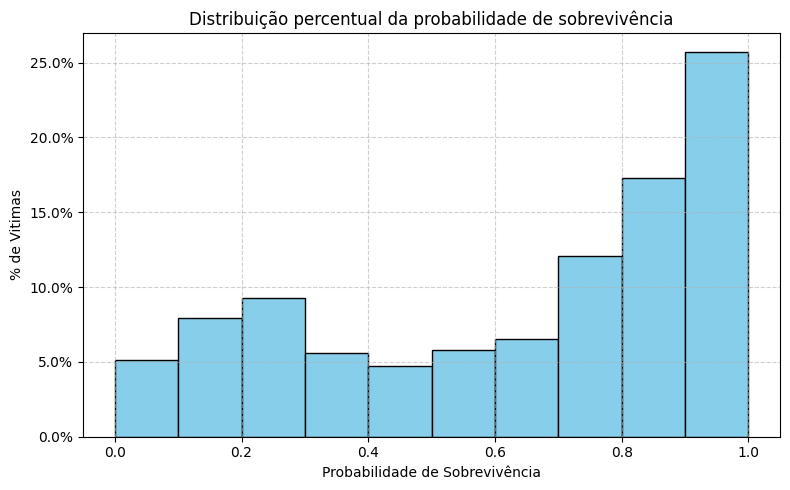

In [14]:
#dataset com a seed de teste e 1000v

df_teste_cego = gerar_dataset_vitimas(
    n_vitimas=1000,
    media_idade=MEDIA_IDADE,
    desvio_idade=DESVIO_IDADE,
    tipo_acidente=TIPO_ACIDENTE,
    nivel_ruido=NIVEL_RUIDO,
    seed=SEED_TESTE
)

In [16]:
# variável alvo (target)
y_teste = df_teste_cego["sobr"]

# colunas proibidas pelo trabalho
colunas_proibidas = ["gcs", "avpu", "tri", "sobr"]

# features (entradas)
X_teste = df_teste_cego.drop(columns=colunas_proibidas)

print("Features utilizadas:")
print(list(X_teste.columns))

print("\nFormato de X_teste:", X_teste.shape)
print("Formato de y_teste:", y_teste.shape)

Features utilizadas:
['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']

Formato de X_teste: (1000, 10)
Formato de y_teste: (1000,)


In [17]:
#predição com CART
y_pred_cart = modelo_final_cart.predict(X_teste)

#predição com MLP 
X_teste_scaled = scaler.transform(X_teste)
y_pred_mlp = modelo_final_mlp.predict(X_teste_scaled)

In [18]:
from sklearn.metrics import mean_squared_error
mse_final_cart = mean_squared_error(y_teste, y_pred_cart)
mse_final_mlp = mean_squared_error(y_teste, y_pred_mlp)

print(f"--- RESULTADO TESTE CEGO ---")
print(f"MSE CART: {mse_final_cart:.6f}")
print(f"MSE MLP:  {mse_final_mlp:.6f}")

if mse_final_cart < mse_final_mlp:
    print("\nO modelo CART teve melhor desempenho no teste cego.")
else:
   print("\nA Rede Neural (MLP) teve melhor desempenho no teste cego.")

--- RESULTADO TESTE CEGO ---
MSE CART: 0.017748
MSE MLP:  0.018388

O modelo CART teve melhor desempenho no teste cego.


In [36]:
erros_individuais_cart = (y_teste - y_pred_cart)**2
erros_individuais_mlp = (y_teste - y_pred_mlp)**2

std_final_cart = np.std(erros_individuais_cart)
std_final_mlp = np.std(erros_individuais_mlp)

dados_teste_cego = {
    "Métrica (Teste Cego)": ["MSE (Média)", "Desvio Padrão (Erro)"],
    "CART": [mse_final_cart, std_final_cart],
    "RN (MLP)": [mse_final_mlp, std_final_mlp]
}
df_resultado_final_cego = pd.DataFrame(dados_teste_cego)

print("--- DESEMPENHO NO TESTE CEGO (1.000 VÍTIMAS) ---")
display(df_resultado_final_cego)

--- DESEMPENHO NO TESTE CEGO (1.000 VÍTIMAS) ---


,Métrica (Teste Cego),CART,RN (MLP)
0,MSE (Média),0.017748,0.018388
1,Desvio Padrão (Erro),0.028114,0.029403


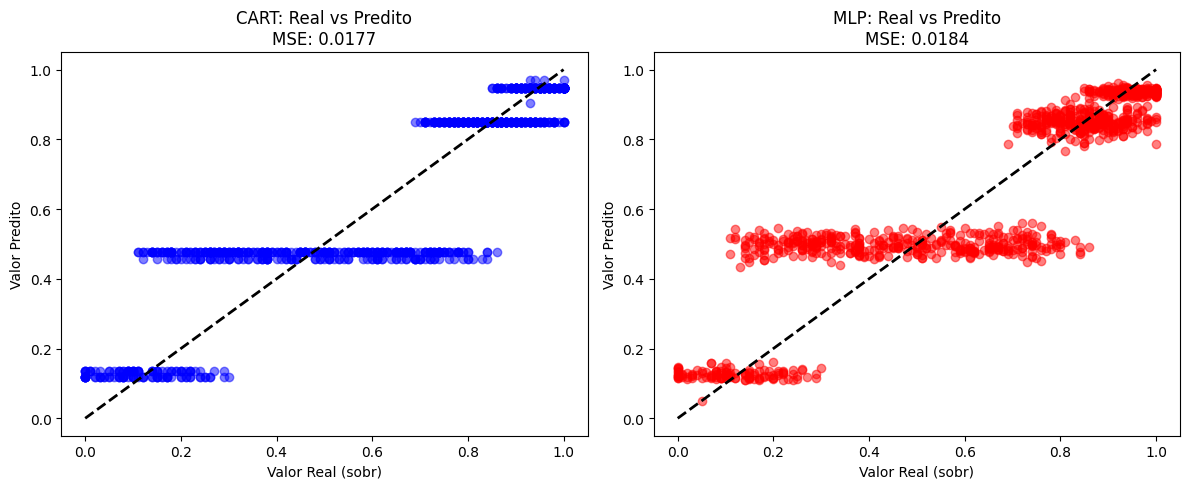

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

#Gráfico CART
plt.subplot(1, 2, 1)
plt.scatter(y_teste, y_pred_cart, alpha=0.5, color='blue')
plt.plot([0, 1], [0, 1], '--k', lw=2) # Linha da perfeição
plt.title(f"CART: Real vs Predito\nMSE: {mse_final_cart:.4f}")
plt.xlabel("Valor Real (sobr)")
plt.ylabel("Valor Predito")

# Gráfico MLP
plt.subplot(1, 2, 2)
plt.scatter(y_teste, y_pred_mlp, alpha=0.5, color='red')
plt.plot([0, 1], [0, 1], '--k', lw=2) # Linha da perfeição
plt.title(f"MLP: Real vs Predito\nMSE: {mse_final_mlp:.4f}")
plt.xlabel("Valor Real (sobr)")
plt.ylabel("Valor Predito")

plt.tight_layout()
plt.show()